TASK 1: IRIS FLOWER CLASSIFICATION

AICTE Oasis Infobyte Internship


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

In [50]:
# 1. LOAD DATASET
print("=" * 60)
print("        IRIS FLOWER CLASSIFICATION")
print("=" * 60)

# Load the built-in Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("\n[1] Dataset Loaded Successfully")
print(f"    Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")

        IRIS FLOWER CLASSIFICATION

[1] Dataset Loaded Successfully
    Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [51]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
print("\n[2] Exploratory Data Analysis")
print("-" * 40)
print(f"\nDataset Info:")
print(df.info())
print(f"\nStatistical Summary:\n{df.describe()}")
print(f"\nClass Distribution:\n{df['species_name'].value_counts()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")


[2] Exploratory Data Analysis
----------------------------------------

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%        


[3] Generating Visualizations...


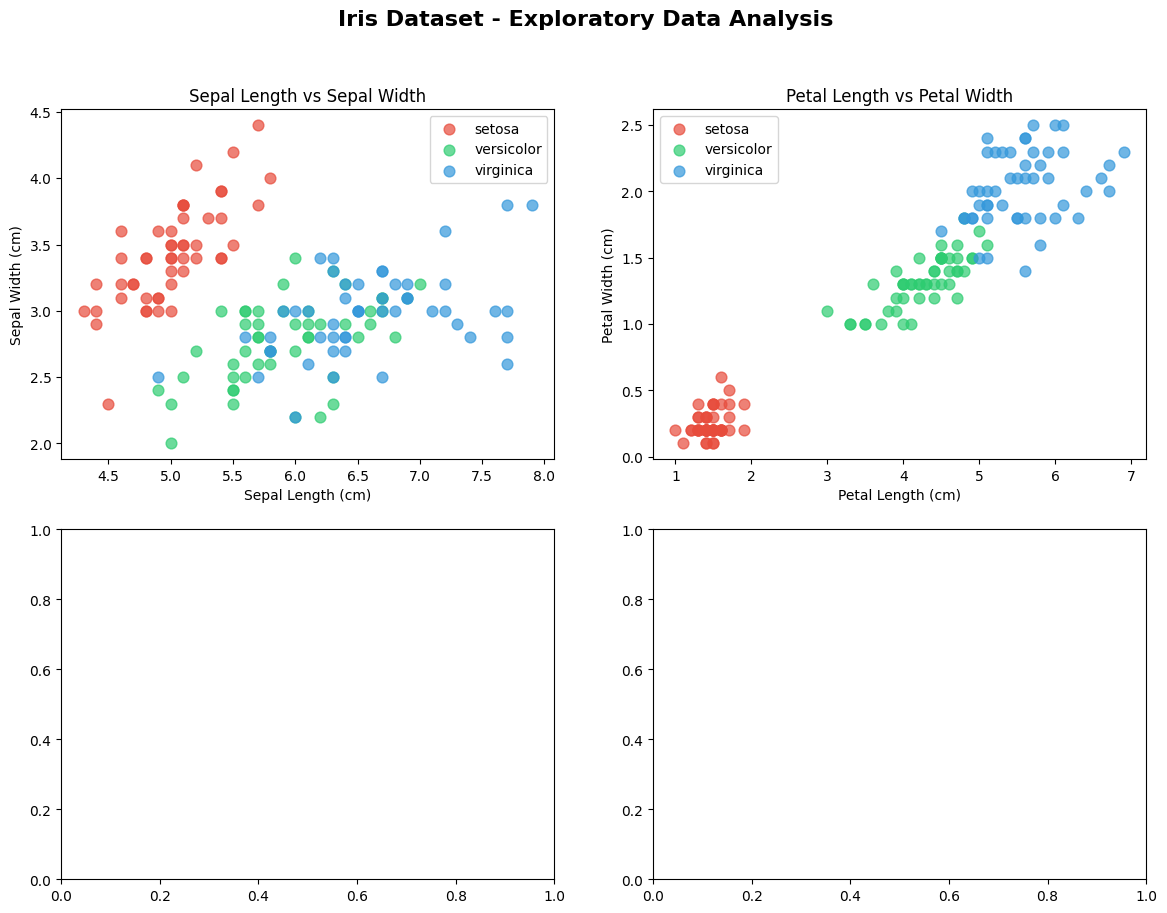

In [52]:
# 3. VISUALIZATIONS
print("\n[3] Generating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Iris Dataset - Exploratory Data Analysis", fontsize=16, fontweight='bold')

# Pairplot equivalent - scatter plots
colors = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
for species, color in colors.items():
    subset = df[df['species_name'] == species]
    axes[0, 0].scatter(subset['sepal length (cm)'], subset['sepal width (cm)'],
                       label=species, color=color, alpha=0.7, s=60)
axes[0, 0].set_xlabel('Sepal Length (cm)')
axes[0, 0].set_ylabel('Sepal Width (cm)')
axes[0, 0].set_title('Sepal Length vs Sepal Width')
axes[0, 0].legend()

for species, color in colors.items():
    subset = df[df['species_name'] == species]
    axes[0, 1].scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                       label=species, color=color, alpha=0.7, s=60)
axes[0, 1].set_xlabel('Petal Length (cm)')
axes[0, 1].set_ylabel('Petal Width (cm)')
axes[0, 1].set_title('Petal Length vs Petal Width')
axes[0, 1].legend()

In [53]:
# Boxplot
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
df_melt = df.melt(id_vars='species_name', value_vars=features, var_name='Feature', value_name='Value')
species_list = df['species_name'].unique()
bp_data = [df[df['species_name'] == s][features].values.flatten() for s in species_list]
axes[1, 0].boxplot([df[df['species_name'] == s]['petal length (cm)'] for s in species_list],
                   labels=species_list, patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title('Petal Length Distribution by Species')
axes[1, 0].set_ylabel('Petal Length (cm)')

Text(23.874999999999993, 0.5, 'Petal Length (cm)')

In [54]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iris_correlation.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved: iris_correlation.png")

    Saved: iris_correlation.png



Displaying Feature Correlation Heatmap:


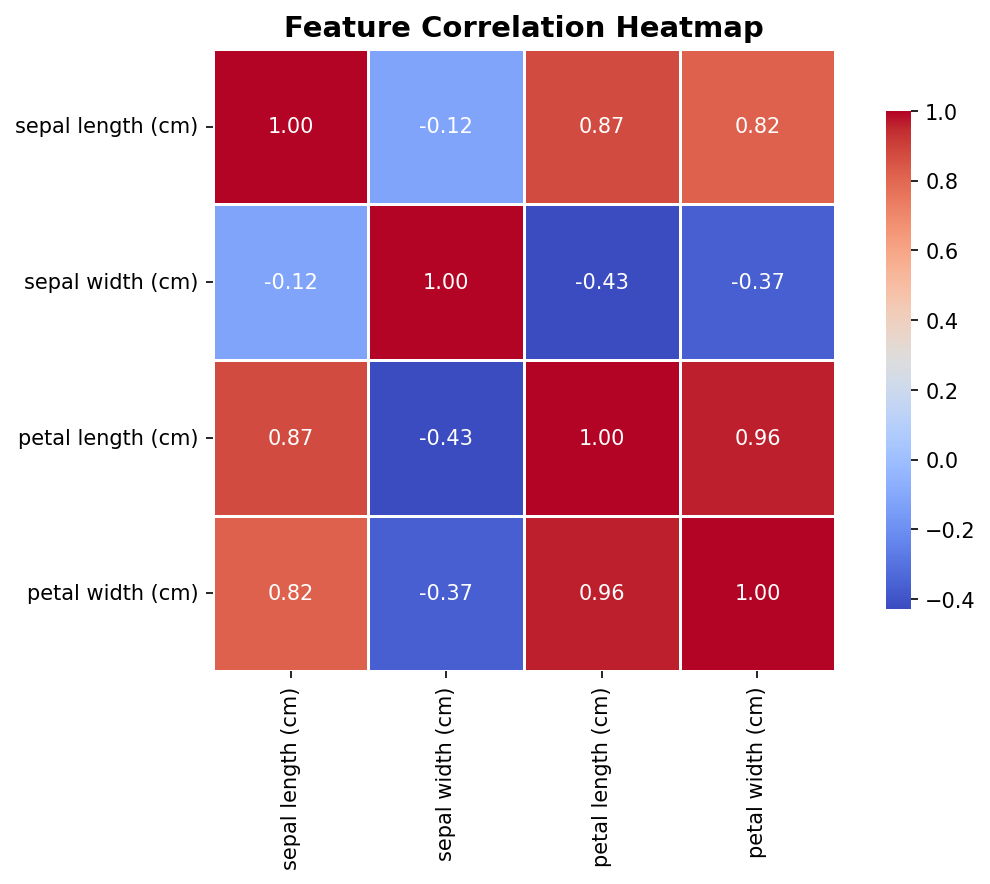

In [55]:
from IPython.display import Image
print("\nDisplaying Feature Correlation Heatmap:")
Image(filename='iris_correlation.png')

In [56]:
# 4. FEATURE ENGINEERING & PREPROCESSING
print("\n[4] Preprocessing Data...")

X = df[features]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"    Training set: {X_train.shape[0]} samples")
print(f"    Testing set : {X_test.shape[0]} samples")


[4] Preprocessing Data...
    Training set: 120 samples
    Testing set : 30 samples


In [57]:
# 5. MODEL TRAINING & COMPARISON
print("\n[5] Training Multiple Models...")
print("-" * 40)

models = {
    'Logistic Regression':    LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                    SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = {
        'model': model,
        'accuracy': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    print(f"    {name:<25} | Test Acc: {acc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



[5] Training Multiple Models...
----------------------------------------
    Logistic Regression       | Test Acc: 0.9333 | CV: 0.9583 ± 0.0264
    Decision Tree             | Test Acc: 0.9333 | CV: 0.9417 ± 0.0204
    Random Forest             | Test Acc: 0.9000 | CV: 0.9500 ± 0.0167
    SVM                       | Test Acc: 0.9667 | CV: 0.9667 ± 0.0312
    K-Nearest Neighbors       | Test Acc: 0.9333 | CV: 0.9667 ± 0.0312
    Gradient Boosting         | Test Acc: 0.9667 | CV: 0.9583 ± 0.0264



[6] Best Model: SVM (Accuracy: 0.9667)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Text(0.5, 1.0, 'Confusion Matrix\n(SVM)')

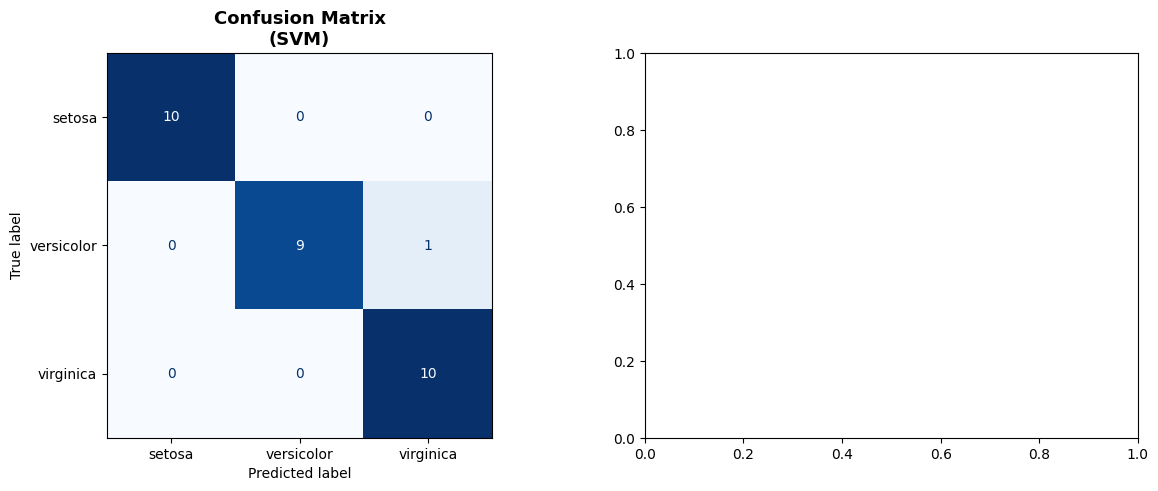

In [58]:
# 6. BEST MODEL ANALYSIS
best_name = max(results, key=lambda k: results[k]['accuracy'])
best = results[best_name]
print(f"\n[6] Best Model: {best_name} (Accuracy: {best['accuracy']:.4f})")
print("\nClassification Report:")
print(classification_report(y_test, best['y_pred'],
                             target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
cm_fig, cm_axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=cm_axes[0], cmap='Blues', colorbar=False)
cm_axes[0].set_title(f'Confusion Matrix\n({best_name})', fontsize=13, fontweight='bold')

In [59]:
# Model Comparison Bar Chart
plt.figure(figsize=(8, 6)) # Create a new figure for this plot
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
bar_colors = ['#e74c3c' if m == best_name else '#3498db' for m in model_names]
bars = plt.bar(range(len(model_names)), accuracies, color=bar_colors, alpha=0.85, edgecolor='black')
plt.xticks(range(len(model_names)), [m.replace(' ', '\n') for m in model_names], fontsize=9)
plt.ylim(0.85, 1.02)
plt.ylabel('Accuracy')
plt.title('Model Comparison', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('iris_model_results.png', dpi=150, bbox_inches='tight')
plt.close() # Close the figure after saving to free up memory
print("    Saved: iris_model_results.png")

    Saved: iris_model_results.png



[7] Displaying Model Comparison Bar Chart:


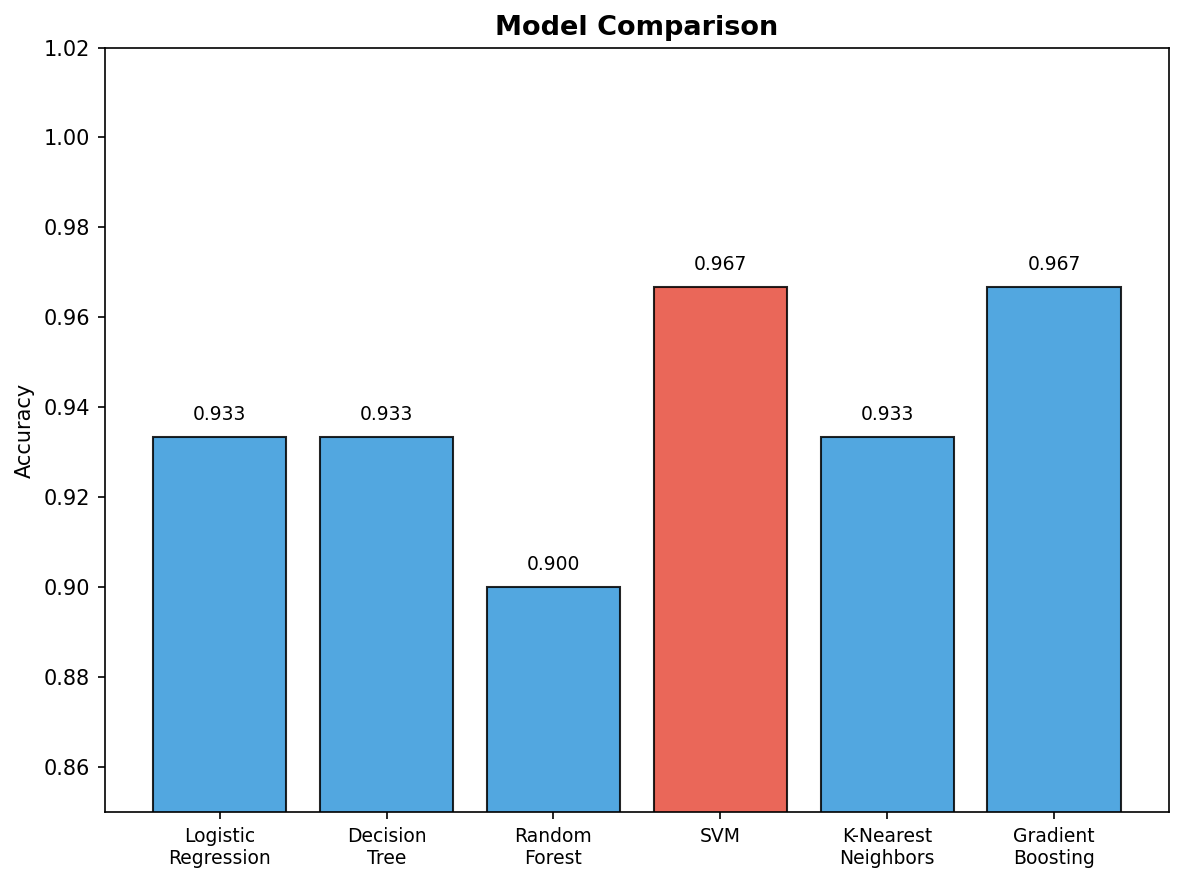

In [60]:
from IPython.display import Image
print("\n[7] Displaying Model Comparison Bar Chart:")
Image(filename='iris_model_results.png')

In [61]:
# 7. FEATURE IMPORTANCE (Random Forest)
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 5))
indices = np.argsort(importances)[::-1]
plt.bar(range(4), importances[indices], color='steelblue', alpha=0.85, edgecolor='black')
plt.xticks(range(4), [features[i] for i in indices], rotation=15, ha='right')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('iris_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved: iris_feature_importance.png")

    Saved: iris_feature_importance.png



[8] Displaying Feature Importance (Random Forest) Chart


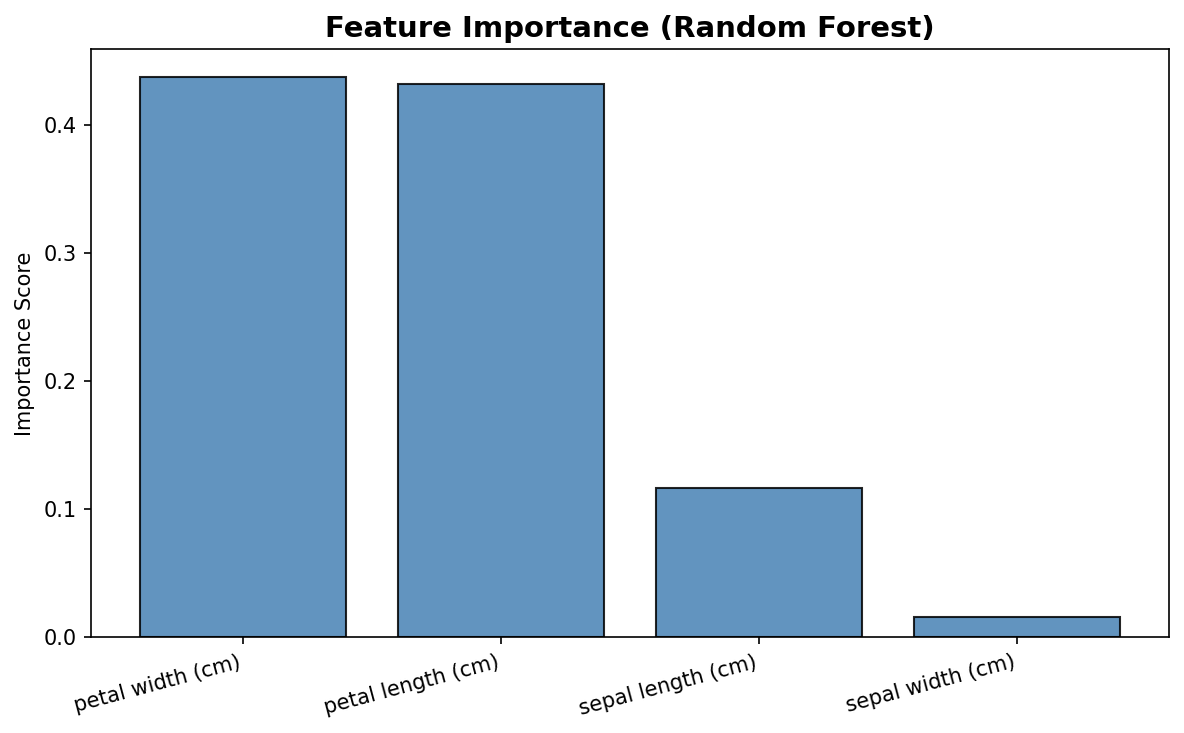

In [62]:
print("\n[8] Displaying Feature Importance (Random Forest) Chart")
Image(filename='iris_feature_importance.png')

In [63]:
# 8. HYPERPARAMETER TUNING (Best Model)
print("\n[7] Hyperparameter Tuning (Random Forest)...")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_rf = grid_search.best_estimator_
tuned_acc = accuracy_score(y_test, best_rf.predict(X_test_scaled))
print(f"    Best Params : {grid_search.best_params_}")
print(f"    Tuned Accuracy: {tuned_acc:.4f}")


[7] Hyperparameter Tuning (Random Forest)...
    Best Params : {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
    Tuned Accuracy: 0.9667


In [64]:
# 9. PREDICTION DEMO
print("\n[8] Sample Predictions:")
sample = np.array([[5.1, 3.5, 1.4, 0.2],   # setosa
                   [6.0, 2.7, 5.1, 1.6],   # versicolor
                   [7.2, 3.6, 6.1, 2.5]])  # virginica
sample_scaled = scaler.transform(sample)
preds = best_rf.predict(sample_scaled)
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
for i, (feat, pred) in enumerate(zip(sample, preds)):
    print(f"    Sample {i+1}: {feat} → Predicted: {species_map[pred]}")

print("\n" + "=" * 60)
print("  IRIS CLASSIFICATION COMPLETE!")
print("=" * 60)


[8] Sample Predictions:
    Sample 1: [5.1 3.5 1.4 0.2] → Predicted: setosa
    Sample 2: [6.  2.7 5.1 1.6] → Predicted: virginica
    Sample 3: [7.2 3.6 6.1 2.5] → Predicted: virginica

  IRIS CLASSIFICATION COMPLETE!
